In [40]:
import pandas as pd
import numpy as np
import glob
import os
import sys
import statsmodels.stats.multitest as smm
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

#supress SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

In [41]:
def rank_sets_by_best_association_minP(df):
    """
    Ranks sets based on the single best feature association (lowest p-value) 
    within each set.
    
    Parameters:
    df (pd.DataFrame): Dataframe containing 'set_id', 'feature_id', 
                       'p_value', 'beta', and 'std_err'.
                       
    Returns:
    pd.DataFrame: A dataframe of sets ranked from best to worst.
    """
    
    # 1. Calculate absolute Beta for tie-breaking logic.
    # If two sets have the exact same minimum p-value, the one with the 
    # stronger effect size (magnitude of beta) should be ranked higher.
    df['abs_beta'] = df['beta'].abs()
    
    # 2. Sort the entire dataframe to prioritise the best features.
    # Primary sort: p_value (Ascending) -> Smaller is better.
    # Secondary sort: abs_beta (Descending) -> Larger impact is better (tie-breaker).
    df_sorted = df.sort_values(by=['p_value', 'abs_beta'], ascending=[True, False])
    
    # 3. Extract the 'Best Association' per Set.
    # We group by 'set_id' and take the 'first' entry. Because we sorted above,
    # the first entry is guaranteed to be the feature with the lowest p-value
    # (and highest beta if p-values were tied).
    best_associations = df_sorted.drop_duplicates(subset=['set_id'], keep='first').copy()
    
    # 4. Create the final Ranking.
    # Reset index to clean up the dataframe.
    best_associations = best_associations.reset_index(drop=True)
    
    # Assign a rank (1 = Best Set).
    best_associations['set_rank'] = best_associations.index + 1
    
    # Select and rename columns for the final report
    output_columns = ['set_rank', 'set_id', 'feature_id', 'p_value', 'beta', 'std_err']
    final_ranking = best_associations[output_columns]
    
    return final_ranking

In [42]:
def compute_scientific_prior(expected_odds_ratio, confidence=0.95):
    """
    Calculates the scientifically appropriate prior variance (W) based on 
    domain knowledge about expected effect sizes.
    """
    # Calculate Z-score dynamically using the Inverse CDF (PPF).
    # For 95% confidence (two-tailed), we look for the point where 
    # (1 + 0.95) / 2 = 0.975 of the mass is to the left.
    z_score = norm.ppf((1 + confidence) / 2)
    
    log_or = np.log(expected_odds_ratio)
    prior_variance = (log_or / z_score) ** 2
    
    return prior_variance

def estimate_empirical_prior(df, p_threshold=0.05):
    """
    Estimates the prior variance (W) directly from the data (Empirical Bayes).
    
    Logic:
    It looks at the distribution of betas for significant features and sets the 
    prior variance such that the model 'expects' effects of the magnitude 
    actually observed in the study.
    
    Parameters:
    df (pd.DataFrame): The dataset containing 'beta' and 'p_value'.
    p_threshold (float): Threshold to define 'plausible signals' for estimation.
    
    Returns:
    float: The empirical prior variance (W).
    """
    # 1. Filter for potential real signals
    hits = df[df['p_value'] < p_threshold].copy()

    # 2. Determine the 95th percentile of the absolute effect sizes (Betas).
    # This value represents the "upper bound" of typical effects in this dataset.
    beta_95 = hits['beta'].abs().quantile(0.95)
    
    # 3. Back-calculate W.
    # The 95th percentile of the folded normal distribution (absolute values)
    # corresponds to the Z-score for 95% confidence (approx 1.96).
    # Formula: z = norm.ppf((1 + confidence) / 2)
    z_score_95 = norm.ppf((1 + 0.95) / 2)
    
    # W = (beta_95 / z_score)^2
    empirical_W = (beta_95 / z_score_95) ** 2
    
    return empirical_W

def calculate_wakefield_abf(beta, se, prior_variance=0.04):
    """
    Calculates the Approximate Bayes Factor (ABF) using Wakefield's method.
    Returns the Log10(ABF).
    """
    # Z-score squared
    z_score = beta / se
    z2 = z_score ** 2
    
    # Variance of the estimate (V)
    v = se ** 2
    
    # Shrinkage factor (r)
    r = prior_variance / (v + prior_variance)
    
    # Wakefield's ABF (log scale natural)
    lbf = 0.5 * (np.log(1 - r) + (z2 * r))
    log10_bf = lbf / np.log(10)
    
    return log10_bf

def rank_sets_by_best_association_abf(df, prior_variance=None):
    """
    Ranks sets based on the single best feature association using 
    Approximate Bayes Factors (ABF).
    """
    
    # If prior is not explicitly provided, estimate it empirically from the data
    if prior_variance is None:
        print("No prior variance provided. Estimating from data (Empirical Bayes)...")
        prior_variance = estimate_empirical_prior(df)
        print(f"Estimated Prior Variance (W): {prior_variance:.5f}")

    # 1. Calculate Log10 Bayes Factor (ABF).
    df['log10_ABF'] = df.apply(
        lambda x: calculate_wakefield_abf(x['beta'], x['std_err'], prior_variance), 
        axis=1
    )
    
    # 2. Sort the entire dataframe.
    # Primary sort: log10_ABF (Descending) -> Higher evidence is better.
    # Secondary sort: p_value (Ascending) -> Fallback if BFs are identical.
    df_sorted = df.sort_values(by=['log10_ABF', 'p_value'], ascending=[False, True])
    
    # 3. Extract the 'Best Association' per Set.
    best_associations = df_sorted.drop_duplicates(subset=['set_id'], keep='first').copy()
    
    # 4. Create the final Ranking.
    best_associations = best_associations.reset_index(drop=True)
    best_associations['set_rank'] = best_associations.index + 1
    
    # Select and rename columns for the final report
    output_columns = ['set_rank', 'set_id', 'feature_id', 'log10_ABF', 'p_value', 'beta', 'std_err']
    final_ranking = best_associations[output_columns]
    
    return final_ranking

In [43]:
def rank_and_decide(input_dir, method="minP"):
    files = glob.glob(os.path.join(input_dir, "*_associations.tsv"))
    
    if not files:
        print(f"Error: No association files found in {input_dir}")
        return

    print(f"--- Analysing {len(files)} models ---")

    all_dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, sep='\t')
            filename = os.path.basename(f).replace('_associations.tsv', '')
            df['set_id'] = filename
            all_dfs.append(df)
        except Exception as e:
            print(f"Error reading {f}: {e}")
    
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df.rename(columns={'Latent': 'feature_id', 'P': 'p_value', 'Effect Size': 'beta', 'StdError': 'std_err'}, inplace=True)
    
    all_ranked_dfs = []
    for d in combined_df.Disease.unique():
        subset_df = combined_df[combined_df.Disease == d]
        
        if method == "minP":
            ranked_df = rank_sets_by_best_association_minP(subset_df)
        elif method == "abf":
            ranked_df = rank_sets_by_best_association_abf(subset_df)
        else:
            print(f"Error: Unknown ranking method '{method}'")
            return
        ranked_df['Disease'] = d
        
        all_ranked_dfs.append(ranked_df)

    return pd.concat(all_ranked_dfs, ignore_index=True)

In [44]:
rank_df = rank_and_decide("/group/glastonbury/soumick/rough/dis_assoc_liv_Emma/", method="abf")
rank_df

--- Analysing 12 models ---
No prior variance provided. Estimating from data (Empirical Bayes)...
Estimated Prior Variance (W): 0.00814
No prior variance provided. Estimating from data (Empirical Bayes)...
Estimated Prior Variance (W): 0.01056
No prior variance provided. Estimating from data (Empirical Bayes)...
Estimated Prior Variance (W): 0.00798
No prior variance provided. Estimating from data (Empirical Bayes)...
Estimated Prior Variance (W): 0.00937
No prior variance provided. Estimating from data (Empirical Bayes)...
Estimated Prior Variance (W): 0.01285


,set_rank,set_id,feature_id,log10_ABF,p_value,beta,std_err,Disease
0,1,qn_latents_liver_FITPARAM_full_img_128_1_seed_...,Z103,31.428799,4.340872e-35,0.199744,0.016151,Disorders of lipoprotein metabolism and other ...
1,2,qn_latents_liver_FITPARAM_full_img_32_1_seed_f...,Z2,30.555596,5.889779e-34,0.163730,0.013469,Disorders of lipoprotein metabolism and other ...
2,3,qn_latents_liver_FITPARAM_full_img_64_1_seed_f...,Z21,21.233780,5.989574e-25,-0.223867,0.021692,Disorders of lipoprotein metabolism and other ...
3,4,qn_latents_liver_FITPARAM_full_img_16_1_seed_f...,Z5,17.257092,1.467773e-20,0.182283,0.019603,Disorders of lipoprotein metabolism and other ...
4,5,qn_latents_liver_FITPARAM_seg_128_1_seed_filt_...,Z62,17.175442,1.333468e-20,0.199658,0.021448,Disorders of lipoprotein metabolism and other ...
5,6,qn_latents_liver_FITPARAM_full_img_8_1_seed_fi...,Z6,16.843842,4.214509e-20,-0.176947,0.019263,Disorders of lipoprotein metabolism and other ...
6,7,qn_latents_liver_FITPARAM_seg_128ch_8_1_seed_f...,Z6,15.679302,7.552646e-19,0.167119,0.018842,Disorders of lipoprotein metabolism and other ...
7,8,qn_latents_liver_FITPARAM_seg_64_1_seed_filt_a...,Z22,11.491461,1.865776e-14,-0.151797,0.019813,Disorders of lipoprotein metabolism and other ...
8,9,qn_latents_liver_FITPARAM_seg_32_1_seed_filt_a...,Z16,10.654611,1.485222e-13,0.144276,0.019522,Disorders of lipoprotein metabolism and other ...
9,10,qn_latents_liver_FITPARAM_seg_8_1_seed_filt_an...,Z4,8.594375,2.061374e-11,0.144825,0.021606,Disorders of lipoprotein metabolism and other ...


In [45]:
df_unique = rank_df.groupby(['Disease', 'set_id'])['set_rank'].min().reset_index()
winners = df_unique[df_unique['set_rank'] == 1].sort_values('Disease')

print("--- Winner per Disease ---")
print(winners[['Disease', 'set_id']])

win_counts = winners['set_id'].value_counts().reset_index()
win_counts.columns = ['set_id', 'total_wins']

print("\n--- Total Wins by Set ---")
print(win_counts)

--- Winner per Disease ---
                                              Disease  \
0   Disorders of lipoprotein metabolism and other ...   
17                          Fatty liver disease (FLD)   
24                                     Hyperlipidemia   
36  Nonspecific abnormal results of function study...   
48                                    Type 2 diabetes   

                                               set_id  
0   qn_latents_liver_FITPARAM_full_img_128_1_seed_...  
17  qn_latents_liver_FITPARAM_seg_128_1_seed_filt_...  
24  qn_latents_liver_FITPARAM_full_img_128_1_seed_...  
36  qn_latents_liver_FITPARAM_full_img_128_1_seed_...  
48  qn_latents_liver_FITPARAM_full_img_128_1_seed_...  

--- Total Wins by Set ---
                                              set_id  total_wins
0  qn_latents_liver_FITPARAM_full_img_128_1_seed_...           4
1  qn_latents_liver_FITPARAM_seg_128_1_seed_filt_...           1


In [46]:
# Group by set_id to calculate aggregate statistics
meta_ranking = df_unique.groupby('set_id')['set_rank'].agg(
    Mean_Rank='mean',
    Median_Rank='median',
    Worst_Rank='max',
    Std_Dev='std'
)

# Calculate Win Rate
total_diseases = df_unique['Disease'].nunique()
meta_ranking['Win_Rate'] = df_unique[df_unique['set_rank'] == 1].groupby('set_id')['set_rank'].count() / total_diseases
meta_ranking['Win_Rate'] = meta_ranking['Win_Rate'].fillna(0) # Fill sets with 0 wins

# Calculate Top 3 Rate (Consistency)
meta_ranking['Top_3_Rate'] = df_unique[df_unique['set_rank'] <= 3].groupby('set_id')['set_rank'].count() / total_diseases
meta_ranking['Top_3_Rate'] = meta_ranking['Top_3_Rate'].fillna(0)

# Sort by Mean Rank (Best to Worst)
meta_ranking = meta_ranking.sort_values('Mean_Rank')

meta_ranking

,Mean_Rank,Median_Rank,Worst_Rank,Std_Dev,Win_Rate,Top_3_Rate
set_id,,,,,,
qn_latents_liver_FITPARAM_full_img_128_1_seed_filt_ancestry,1.4,1.0,3,0.894427,0.8,1.0
qn_latents_liver_FITPARAM_full_img_64_1_seed_filt_ancestry,4.6,4.0,9,2.509980,0.0,0.4
qn_latents_liver_FITPARAM_seg_128_1_seed_filt_ancestry,4.6,5.0,8,2.701851,0.2,0.4
qn_latents_liver_FITPARAM_full_img_32_1_seed_filt_ancestry,5.0,2.0,12,4.472136,0.0,0.6
qn_latents_liver_FITPARAM_seg_64_1_seed_filt_ancestry,5.2,4.0,8,2.167948,0.0,0.2
qn_latents_liver_FITPARAM_full_img_16_1_seed_filt_ancestry,7.0,8.0,9,2.345208,0.0,0.0
qn_latents_liver_FITPARAM_seg_32_1_seed_filt_ancestry,7.0,7.0,9,1.224745,0.0,0.0
qn_latents_liver_FITPARAM_full_img_8_1_seed_filt_ancestry,7.6,6.0,12,3.209361,0.0,0.0
qn_latents_liver_FITPARAM_seg_64ch_8_1_seed_filt_ancestry,7.6,11.0,12,5.128353,0.0,0.4


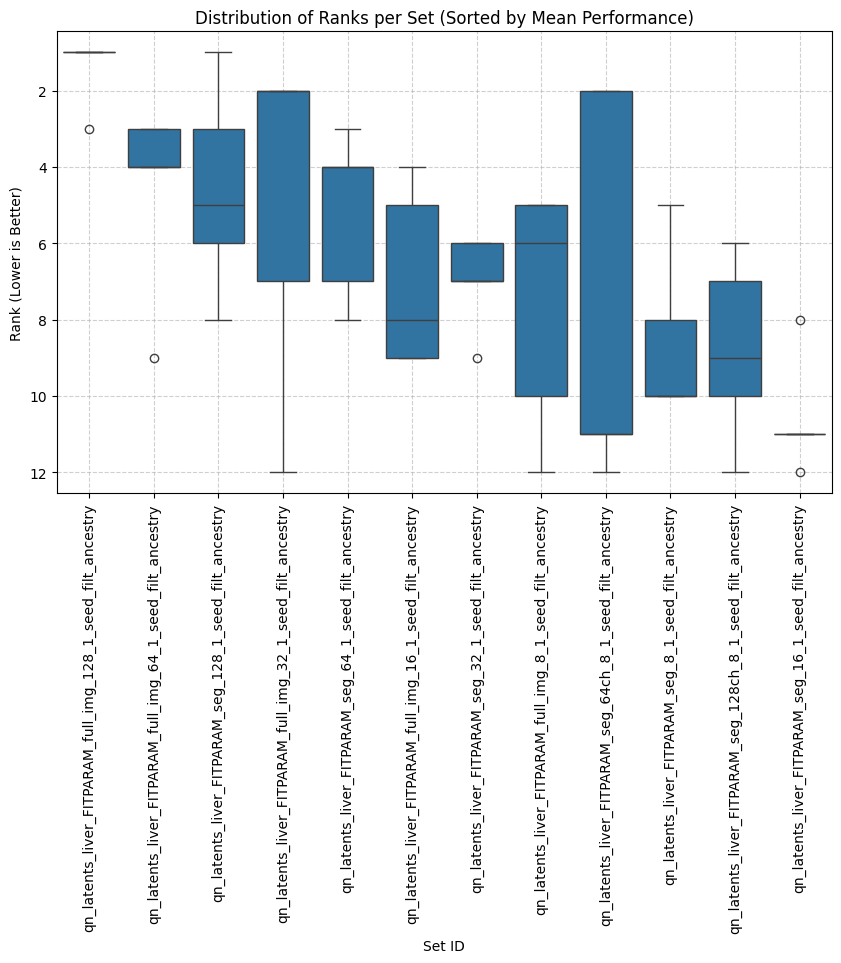

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='set_id', y='set_rank', data=df_unique, order=meta_ranking.index)
plt.title('Distribution of Ranks per Set (Sorted by Mean Performance)')
plt.ylabel('Rank (Lower is Better)')
plt.xlabel('Set ID')
plt.xticks(rotation=90)
plt.gca().invert_yaxis() # Invert Y axis so Rank 1 is at the top
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()